In [7]:
# --- SBERT & NCF Feasibility Test Notebook ---

import pandas as pd
import numpy as np
import torch
from sentence_transformers import SentenceTransformer, util
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torch import nn

In [8]:
# --- Load and subset data ---
merged_df = pd.read_csv('../data/cleaned/merged_cleaned_data.csv')
lectures_df = pd.read_csv('../data/cleaned/cleaned_lectures.csv')

subset_users = merged_df['user_id'].unique()[:10]
subset_df = merged_df[merged_df['user_id'].isin(subset_users)]

subset_items = subset_df['bundle_id'].unique()[:20]
subset_df = subset_df[subset_df['bundle_id'].isin(subset_items)]


Cosine Similarity (First 5x5):
tensor([[0.]])


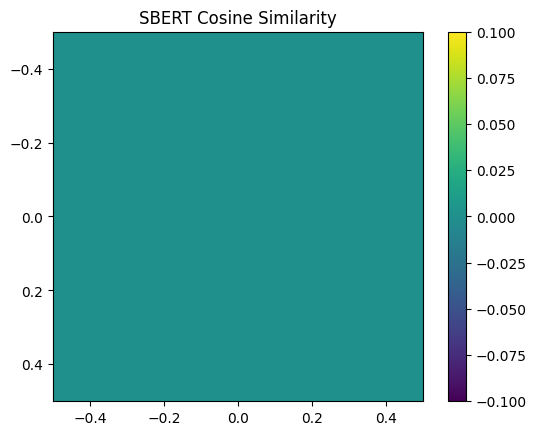

In [11]:
lectures_df["pseudo_text"] = lectures_df.apply(
    lambda row: f"Part {row['part']} | Tags: {row['tags']}", axis=1
)

from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt

subset_ids = [f"l{i}" for i in subset_items]
sample_texts = lectures_df[lectures_df['lecture_id'].isin(subset_ids)]['pseudo_text'].fillna("").tolist()

sbert = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = sbert.encode(sample_texts, convert_to_tensor=True)

similarity_matrix = util.pytorch_cos_sim(embeddings, embeddings)

print("Cosine Similarity (First 5x5):")
print(similarity_matrix[:5, :5])

plt.imshow(similarity_matrix.cpu().numpy(), cmap="viridis")
plt.colorbar()
plt.title("SBERT Cosine Similarity")
plt.show()

In [13]:
print("\n--- NCF Collaborative Filtering Feasibility ---")

# Encode user/item
user_map = {uid: i for i, uid in enumerate(subset_df['user_id'].unique())}
item_map = {bid: i for i, bid in enumerate(subset_df['bundle_id'].unique())}

subset_df['user_idx'] = subset_df['user_id'].map(user_map)
subset_df['item_idx'] = subset_df['bundle_id'].map(item_map)
subset_df['label'] = subset_df['is_correct'].astype(float)

X = subset_df[['user_idx', 'item_idx']].values
y = subset_df['label'].values

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


--- NCF Collaborative Filtering Feasibility ---


Epoch 1: Loss = 0.6695
Epoch 2: Loss = 0.6359
Epoch 3: Loss = 0.6060
Epoch 4: Loss = 0.5798
Epoch 5: Loss = 0.5568
Epoch 6: Loss = 0.5366
Epoch 7: Loss = 0.5193
Epoch 8: Loss = 0.5047
Epoch 9: Loss = 0.4919
Epoch 10: Loss = 0.4806


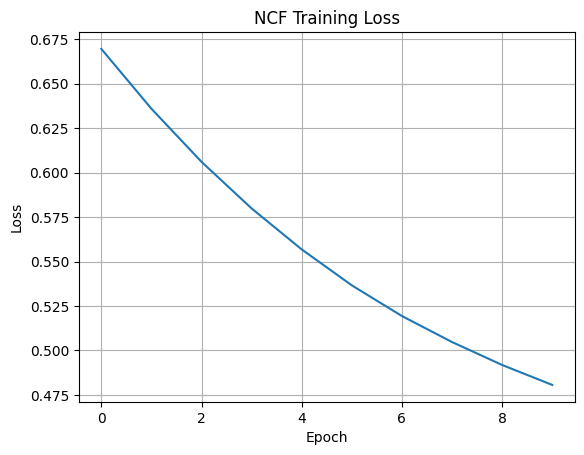

Validation RMSE: 0.5174


In [14]:
# NCF Model
class NCF(nn.Module):
    def __init__(self, num_users, num_items, n_factors=8):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, n_factors)
        self.item_emb = nn.Embedding(num_items, n_factors)
        self.fc1 = nn.Linear(n_factors * 2, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, users, items):
        u = self.user_emb(users)
        i = self.item_emb(items)
        x = torch.cat([u, i], dim=-1)
        x = torch.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(x)).squeeze()

model = NCF(len(user_map), len(item_map))
opt = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCELoss()

train_users = torch.tensor(X_train[:,0], dtype=torch.long)
train_items = torch.tensor(X_train[:,1], dtype=torch.long)
train_labels = torch.tensor(y_train, dtype=torch.float32)

val_users = torch.tensor(X_val[:,0], dtype=torch.long)
val_items = torch.tensor(X_val[:,1], dtype=torch.long)
val_labels = torch.tensor(y_val, dtype=torch.float32)

losses = []
for epoch in range(10):
    model.train()
    opt.zero_grad()
    preds = model(train_users, train_items)
    loss = loss_fn(preds, train_labels)
    loss.backward()
    opt.step()
    losses.append(loss.item())
    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

plt.plot(losses)
plt.title("NCF Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Evaluate
model.eval()
with torch.no_grad():
    val_preds = model(val_users, val_items)
    rmse = torch.sqrt(((val_preds - val_labels) ** 2).mean()).item()
    print(f"Validation RMSE: {rmse:.4f}")